In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

In [5]:
# Load MNIST dataset

# https://yann.lecun.com/exdb/mnist/
# https://pytorch.org/docs/stable/data.html#module-torch.utils.data
# https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html

train_dataset = datasets.MNIST(root='data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='data', train=False, transform=transform, download=True)

100.0%
100.0%
100.0%
100.0%


2
3
torch.Size([1, 28, 28])
Image label is : 5


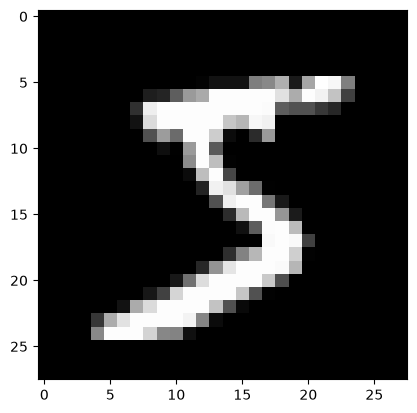

In [6]:
print(len(train_dataset.__getitem__(0)))
print(len(train_dataset.__getitem__(0)[0].shape))
print(train_dataset.__getitem__(0)[0].shape)
print(f"Image label is : {train_dataset.__getitem__(0)[1]}")
plt.imshow(train_dataset.__getitem__(0)[0].squeeze(), cmap="grey")

<class 'torchvision.datasets.mnist.MNIST'>
<class 'torch.Tensor'>
torch.Size([1, 28, 28])


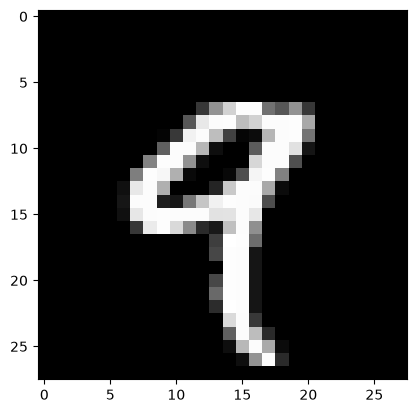

In [7]:
print(type(train_dataset))
print(type(train_dataset[0][0]))
print(train_dataset[0][0].shape)
plt.imshow(train_dataset[4][0].squeeze(), cmap="grey")

In [8]:
batch_size = 64

# Split train dataset into train and validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super(DigitClassifier, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        # self.lrn = nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2)

    def forward(self, x):
        x = x.reshape(-1, 28 * 28)  # Flatten the image
        # x = x.view(-1, 28 * 28)  # Flatten the image
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [10]:
learning_rate = 0.001

In [11]:
model = DigitClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [12]:
# Training function
def train(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy

In [13]:
# Validation function
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        batch = 1
        for images, labels in loader:
            print(f"Current batch : {batch}")
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            print(f"Running loss : {running_loss}")
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            batch += 1

    epoch_loss = running_loss / batch
    accuracy = correct / total
    return epoch_loss, accuracy

In [14]:
num_epochs = 2

In [15]:
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Current batch : 1
Running loss : 0.4198002517223358
Current batch : 2
Running loss : 0.6391327381134033
Current batch : 3
Running loss : 1.018544763326645
Current batch : 4
Running loss : 1.199779137969017
Current batch : 5
Running loss : 1.3114004507660866
Current batch : 6
Running loss : 1.603951670229435
Current batch : 7
Running loss : 1.9972940757870674
Current batch : 8
Running loss : 2.313348241150379
Current batch : 9
Running loss : 2.583288438618183
Current batch : 10
Running loss : 2.9553186371922493
Current batch : 11
Running loss : 3.259470470249653
Current batch : 12
Running loss : 3.545100189745426
Current batch : 13
Running loss : 3.931498743593693
Current batch : 14
Running loss : 4.077690936625004
Current batch : 15
Running loss : 4.306955106556416
Current batch : 16
Running loss : 4.625421203672886
Current batch : 17
Running loss : 4.7836035415530205
Current batch : 18
Running loss : 4.996452622115612
Current batch : 19
Running loss : 5.216288961470127
Current batch :

In [16]:
# Testing
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Current batch : 1
Running loss : 0.11696473509073257
Current batch : 2
Running loss : 0.18877945840358734
Current batch : 3
Running loss : 0.2677704021334648
Current batch : 4
Running loss : 0.5383529588580132
Current batch : 5
Running loss : 0.6925200000405312
Current batch : 6
Running loss : 0.9534566178917885
Current batch : 7
Running loss : 1.111742876470089
Current batch : 8
Running loss : 1.3207412287592888
Current batch : 9
Running loss : 1.5851348862051964
Current batch : 10
Running loss : 1.8388264998793602
Current batch : 11
Running loss : 2.077046252787113
Current batch : 12
Running loss : 2.3159957453608513
Current batch : 13
Running loss : 2.3722641617059708
Current batch : 14
Running loss : 2.5391345620155334
Current batch : 15
Running loss : 2.8246786296367645
Current batch : 16
Running loss : 3.008285492658615
Current batch : 17
Running loss : 3.1685772985219955
Current batch : 18
Running loss : 3.3866899013519287
Current batch : 19
Running loss : 3.6416722536087036
Cur

In [17]:
# Save the model
torch.save(model.state_dict(), "mnist_digit_classifier.pth")
print("Model saved as mnist_digit_classifier.pth")

Model saved as mnist_digit_classifier.pth


# Model Inference

In [18]:
# Load the model
loaded_model = DigitClassifier().to(device)
loaded_model.load_state_dict(torch.load("mnist_digit_classifier.pth"))
loaded_model.eval()
print("Model loaded for inference.")

Model loaded for inference.


In [19]:
# Inference
def predict(model, image):
    model.eval()
    with torch.no_grad():
        image = image.to(device)
        output = model(image)
        _, predicted = output.max(1)
    return predicted.item()

In [20]:
# Function to preprocess the image
def preprocess_image(image):

    image = cv2.bitwise_not(image)

    transform = transforms.Compose([
        transforms.ToPILImage(),             # Convert to PIL image
        # https://pytorch.org/vision/0.8/transforms.html

        transforms.Grayscale(num_output_channels=1),  # Convert to grayscale
        transforms.Resize((28, 28)),        # Resize to match MNIST input size
        transforms.ToTensor(),              # Convert to tensor
        transforms.Normalize((0.5,), (0.5,))  # Normalize
    ])
    image = transform(image)  # Apply transforms
    # image = image.unsqueeze(0)  # Add batch dimension (1, 1, 28, 28)
    return image

In [21]:
import cv2

image = cv2.imread("/content/MS Paint _ Microsoft Paint Online.png")

# Preprocess the image
preprocessed_image = preprocess_image(image)

# Visualize the original and preprocessed image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Show the original image in RGB
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_image.squeeze(), cmap='grey')  # Show the preprocessed image
plt.title("Preprocessed Image")
plt.show()

# Predict the label
predicted_label = predict(model, preprocessed_image)
print(f"Predicted Label: {predicted_label}")


error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\matrix.cpp:1923: error: (-2:Unspecified error) in function 'class cv::Size_<int> __cdecl cv::getContinuousSize2D(class cv::Mat &,class cv::Mat &,class cv::Mat &,int)'
>  (expected: 'total_sz == m3.total()'), where
>     'total_sz' is 0
> must be equal to
>     'm3.total()' is 1


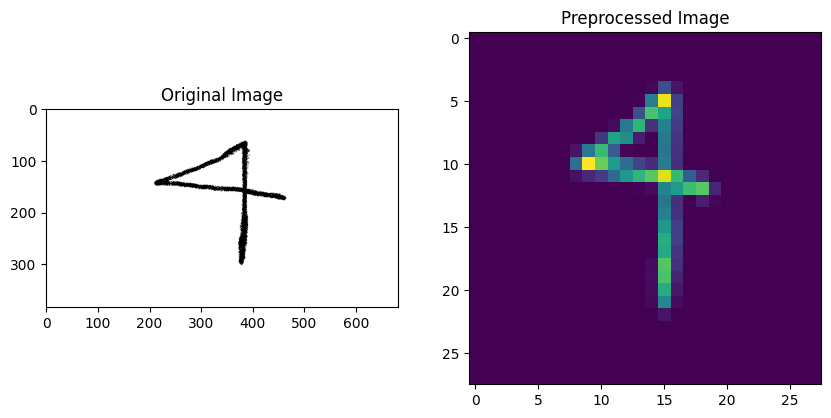

Predicted Label: 1


In [ ]:
import cv2

image = cv2.imread("/content/four.png")

# Preprocess the image
preprocessed_image = preprocess_image(image)

# Visualize the original and preprocessed image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Show the original image in RGB
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_image.squeeze())  # Show the preprocessed image
plt.title("Preprocessed Image")
plt.show()

# Predict the label
predicted_label = predict(model, preprocessed_image)
print(f"Predicted Label: {predicted_label}")


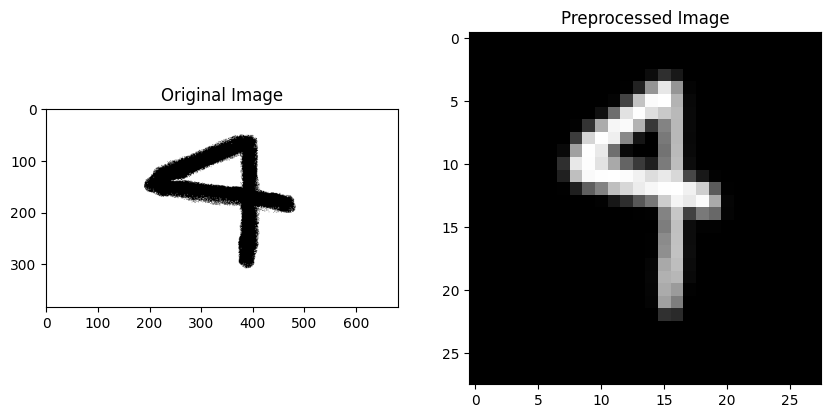

Predicted Label: 9


In [ ]:
import cv2

image = cv2.imread("/content/four_new.png")

# Preprocess the image
preprocessed_image = preprocess_image(image)

# Visualize the original and preprocessed image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Show the original image in RGB
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_image.squeeze(), cmap='grey')  # Show the preprocessed image
plt.title("Preprocessed Image")
plt.show()

# Predict the label
predicted_label = predict(model, preprocessed_image)
print(f"Predicted Label: {predicted_label}")


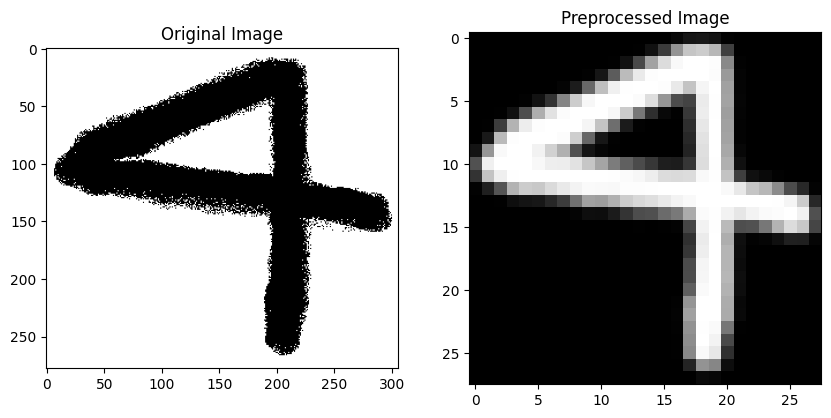

Predicted Label: 7


In [ ]:
import cv2

image = cv2.imread("/content/four_new_resized.png")

# Preprocess the image
preprocessed_image = preprocess_image(image)

# Visualize the original and preprocessed image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Show the original image in RGB
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_image.squeeze(), cmap='grey')  # Show the preprocessed image
plt.title("Preprocessed Image")
plt.show()

# Predict the label
predicted_label = predict(model, preprocessed_image)
print(f"Predicted Label: {predicted_label}")


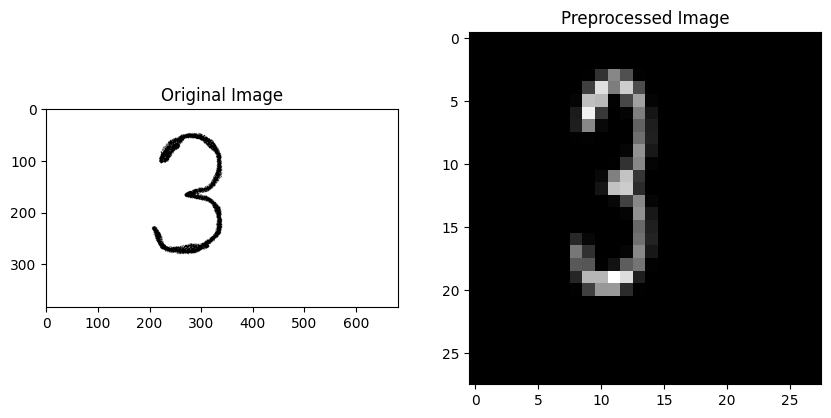

Predicted Label: 2


In [ ]:
import cv2

image = cv2.imread("/content/three.png")

# Preprocess the image
preprocessed_image = preprocess_image(image)

# Visualize the original and preprocessed image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Show the original image in RGB
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_image.squeeze(), cmap='grey')  # Show the preprocessed image
plt.title("Preprocessed Image")
plt.show()

# Predict the label
predicted_label = predict(model, preprocessed_image)
print(f"Predicted Label: {predicted_label}")
